In [1]:
import pandas as pd
import numpy as np
import seaborn as sns # type: ignore
import matplotlib.pyplot as plt

from skbio.diversity import alpha, beta # type: ignore
from skbio.diversity import beta_diversity
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova

In [3]:
metadata = pd.read_csv('/home/valerie/Desktop/Master/metagenomics/HW2/input/human_core_long.tsv', sep='\t')
metadata.info()
metadata.head()

<class 'pandas.DataFrame'>
RangeIndex: 2837472 entries, 0 to 2837471
Data columns (total 4 columns):
 #   Column         Dtype
---  ------         -----
 0   sample_alias   str  
 1   metadata_item  str  
 2   curation_tier  str  
 3   value          str  
dtypes: str(4)
memory usage: 86.6 MB


,sample_alias,metadata_item,curation_tier,value
0,Strazar_2021_Tanzania.sample_TZFG051,study_code,core,Strazar_2021_Tanzania
1,Strazar_2021_Tanzania.sample_TZFG051,spire_sample_name,core,SAMN17126996
2,Strazar_2021_Tanzania.sample_TZFG051,longitude,core,35.71
3,Strazar_2021_Tanzania.sample_TZFG051,latitude,core,-6.23
4,Strazar_2021_Tanzania.sample_TZFG051,geographic_location,core,Tanzania


In [4]:
metadata_wide = metadata.pivot(
    index='sample_alias', 
    columns='metadata_item', 
    values='value'
).reset_index()
print(metadata_wide.columns)
metadata_wide.head()

Index(['sample_alias', 'age_category', 'age_range', 'age_years', 'artificial',
       'available_info', 'bmi', 'collection_date', 'collection_date_end',
       'diet', 'doi', 'environment_biome', 'environment_feature',
       'environment_material', 'environmental_package', 'geographic_location',
       'height_cm', 'intervention', 'last_change', 'latitude', 'location',
       'location_resolution', 'longitude', 'medication',
       'medication_with_parents', 'pmid', 'sex', 'smoker', 'spire_sample_name',
       'study_code', 'subject_disease_status', 'subject_id', 'tax_id',
       'timepoint', 'timeseries_available', 'timeseries_count',
       'timeseries_duration', 'type_of_birth', 'weight_kg'],
      dtype='str', name='metadata_item')


metadata_item,sample_alias,age_category,age_range,age_years,artificial,available_info,bmi,collection_date,collection_date_end,diet,...,study_code,subject_disease_status,subject_id,tax_id,timepoint,timeseries_available,timeseries_count,timeseries_duration,type_of_birth,weight_kg
0,Aggarwala_2020_FMT_RCDI.sample_1001095A,adult,adult,NaN,NaN,NaN,NaN,2000-01-01,2020-12-31,NaN,...,Aggarwala_2020_FMT_RCDI,ulcerative colitis,Aggarwala_2020_FMT_RCDI.subject_1001095,408170,0,yes,7,1825,NaN,NaN
1,Aggarwala_2020_FMT_RCDI.sample_1001095F,adult,adult,NaN,NaN,NaN,NaN,2000-01-01,2020-12-31,NaN,...,Aggarwala_2020_FMT_RCDI,NaN,Aggarwala_2020_FMT_RCDI.subject_1001095,408170,7,yes,7,1825,NaN,NaN
2,Aggarwala_2020_FMT_RCDI.sample_1001095G,adult,adult,NaN,NaN,NaN,NaN,2000-01-01,2020-12-31,NaN,...,Aggarwala_2020_FMT_RCDI,NaN,Aggarwala_2020_FMT_RCDI.subject_1001095,408170,33,yes,7,1825,NaN,NaN
3,Aggarwala_2020_FMT_RCDI.sample_1001095H,adult,adult,NaN,NaN,NaN,NaN,2000-01-01,2020-12-31,NaN,...,Aggarwala_2020_FMT_RCDI,NaN,Aggarwala_2020_FMT_RCDI.subject_1001095,408170,81,yes,7,1825,NaN,NaN
4,Aggarwala_2020_FMT_RCDI.sample_1001095I,adult,adult,NaN,NaN,NaN,NaN,2000-01-01,2020-12-31,NaN,...,Aggarwala_2020_FMT_RCDI,NaN,Aggarwala_2020_FMT_RCDI.subject_1001095,408170,427,yes,7,1825,NaN,NaN


In [5]:
disease_counts = metadata_wide['subject_disease_status'].value_counts()
print(disease_counts.head(20))

subject_disease_status
COHORT                             50980
CTR                                13283
type 2 diabetes                     2326
critically ill patient              1893
Crohn's disease                     1682
ulcerative colitis                  1679
multiple sclerosis                  1635
cystic fibrosis                     1252
Parkinson's disease                 1220
colorectal cancer                   1159
melanoma                             809
Clostridium difficile infection      786
COVID-19                             592
kidney transplant recipient          508
HIV                                  488
metabolic syndrome                   472
control patient                      452
alcoholic liver cirrhosis            439
irritable bowel syndrome             428
severe acute malnutrition            388
Name: count, dtype: int64


In [9]:
cron_ctr_df = metadata_wide[metadata_wide['subject_disease_status'].isin(['Crohn\'s disease', 'CTR'])].copy()
cron_clean = cron_ctr_df.drop_duplicates(subset=['subject_id', 'timepoint', 'age_years']) #since we have duplicates for metadata profiles, we have to keep only one unique sample

cron_clean = cron_clean[cron_clean['sex'].isin(['male', 'female'])] #filter sex
cron_clean = cron_clean[cron_clean['age_category'].str.lower().isin(['adolescent', 'adult'])] #filter age_category
cron_clean = cron_clean[cron_clean['environment_material'] == 'fecal material [ENVO:00002003]'] #filter material source

final_dist = pd.crosstab(cron_clean['subject_disease_status'], 
                         [cron_clean['age_category'], cron_clean['sex']], 
                         margins=True)

print("\n--- Final Research Cohort Distribution ---")
display(final_dist)


--- Final Research Cohort Distribution ---


age_category           adolescent       adult         All
sex                        female male female  male      
subject_disease_status                                   
CTR                            53   52   2987  2828  5920
Crohn's disease                85  166    387   357   995
All                           138  218   3374  3185  6915

In [11]:
abundance_df = pd.read_csv('/home/valerie/Desktop/Master/metagenomics/HW2/input/human_metaphlan4_species_2026-02-15.tsv', sep='\t')

In [12]:
abundance_df.head()

,sample_alias,species,rel_abund
0,Cait_2019_infant.sample_AC114,s__Bacteroides_ovatus,0.00116
1,Cait_2019_infant.sample_AC114,s__Staphylococcus_epidermidis,0.00119
2,Cait_2019_infant.sample_AC114,s__Bacteroides_fragilis,0.00278
3,Cait_2019_infant.sample_AC114,s__Parabacteroides_distasonis,0.00315
4,Cait_2019_infant.sample_AC114,s__Veillonella_dispar,0.00370


In [13]:
target_samples = cron_clean['sample_alias'].unique()
abundance_filtered = abundance_df[abundance_df['sample_alias'].isin(target_samples)].copy()
matrix_df = abundance_filtered.pivot(
    index='sample_alias', 
    columns='species', 
    values='rel_abund'
).fillna(0)

In [14]:
matrix_df.head()

species,s__Abiotrophia_defectiva,s__Abiotrophia_sp_HMSC24B09,s__Absicoccus_porci,s__Acetivibrio_sp_MSJd_27,s__Achromobacter_insuavis,s__Achromobacter_xylosoxidans,s__Acidaminococcus_SGB42794,s__Acidaminococcus_SGB53443,s__Acidaminococcus_SGB5735,s__Acidaminococcus_fermentans,...,s__Zhenhengia_yiwuensis,s__Zhenpiania_hominis,s__Zongyangia_hominis,s__bacterium_1XD42_54,s__bacterium_210820_DFI_6_37,s__bacterium_210917_DFI_7_65,s__bacterium_210917_SL_2_15,s__bacterium_D16_34,s__bacterium_OL_1,s__unidentified_bacterial_endosymbiont
sample_alias,,,,,,,,,,,,,,,,,,,,,
Bai_2021_HIV.Q_H1,0.0,0.0,0.0,0.02586,0.0,0.0,0.0,0.0,0.0,0.00000,...,0.0,0.01139,0.0,0.0,0.0,0.04481,0.0,0.0,0.0,0.0
Bai_2021_HIV.Q_H10,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000,...,0.0,0.00124,0.0,0.0,0.0,0.02576,0.0,0.0,0.0,0.0
Bai_2021_HIV.Q_H11,0.0,0.0,0.0,0.01715,0.0,0.0,0.0,0.0,0.0,0.81517,...,0.0,0.01607,0.0,0.0,0.0,0.03737,0.0,0.0,0.0,0.0
Bai_2021_HIV.Q_H2,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000,...,0.0,0.00944,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
Bai_2021_HIV.Q_H3,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000,...,0.0,0.00000,0.0,0.0,0.0,0.03074,0.0,0.0,0.0,0.0


In [16]:
common_samples_list = list(set(cron_clean['sample_alias']) & set(matrix_df.index))
cron_final = cron_clean[cron_clean['sample_alias'].isin(common_samples_list)].copy()
matrix_numeric = matrix_df.loc[cron_final['sample_alias']]
cron_final = cron_final.reset_index(drop=True)
print(len(cron_final))

5150


In [22]:
matrix_df.columns

Index(['s__Abiotrophia_defectiva', 's__Abiotrophia_sp_HMSC24B09',
       's__Absicoccus_porci', 's__Acetivibrio_sp_MSJd_27',
       's__Achromobacter_insuavis', 's__Achromobacter_xylosoxidans',
       's__Acidaminococcus_SGB42794', 's__Acidaminococcus_SGB53443',
       's__Acidaminococcus_SGB5735', 's__Acidaminococcus_fermentans',
       ...
       's__Zhenhengia_yiwuensis', 's__Zhenpiania_hominis',
       's__Zongyangia_hominis', 's__bacterium_1XD42_54',
       's__bacterium_210820_DFI_6_37', 's__bacterium_210917_DFI_7_65',
       's__bacterium_210917_SL_2_15', 's__bacterium_D16_34',
       's__bacterium_OL_1', 's__unidentified_bacterial_endosymbiont'],
      dtype='str', name='species', length=3787)

In [ ]:
final_combined_df = pd.merge(
    cron_clean, 
    matrix_df, 
    on='sample_alias', 
    how='left'
)

print(f"Total columns: {len(final_combined_df.columns)}")

Total columns: 3826


In [24]:
from scipy.stats import entropy

# 1. Identify species columns (starting with s__)
species_cols = [col for col in final_combined_df.columns if col.startswith('s__')]

# 2. Calculate Shannon Index for each row (sample)
# Shannon index = H = -sum(p * log(p))
final_combined_df['shannon_index'] = final_combined_df[species_cols].apply(
    lambda row: entropy(row) if row.sum() > 0 else 0, axis=1
)

In [26]:
final_combined_df.tail()

,sample_alias,age_category,age_range,age_years,artificial,available_info,bmi,collection_date,collection_date_end,diet,...,s__Zhenpiania_hominis,s__Zongyangia_hominis,s__bacterium_1XD42_54,s__bacterium_210820_DFI_6_37,s__bacterium_210917_DFI_7_65,s__bacterium_210917_SL_2_15,s__bacterium_D16_34,s__bacterium_OL_1,s__unidentified_bacterial_endosymbiont,shannon_index
6910,Zuo_2020_COVID.C5,adult,NaN,49,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.17077,0.0,0.0,0.0,0.01797,0.0,0.0,0.47820,0.0,4.380701
6911,Zuo_2020_COVID.C6,adult,NaN,46,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.00088,0.0,0.0,0.0,0.22353,0.0,0.0,0.00000,0.0,3.550169
6912,Zuo_2020_COVID.C7,adult,NaN,22,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.00000,0.0,0.0,0.0,0.04626,0.0,0.0,0.00000,0.0,3.806056
6913,Zuo_2020_COVID.C8,adult,NaN,35,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.01994,0.0,0.0,0.0,0.00000,0.0,0.0,0.00000,0.0,3.285042
6914,Zuo_2020_COVID.C9,adult,NaN,46,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.02013,0.0,0.0,0.0,0.09882,0.0,0.0,0.21168,0.0,3.912180


In [28]:
def compare_groups(df, group_col, target_col, group1, group2, subset_name="Overall"):
    g1 = df[df[group_col] == group1][target_col]
    g2 = df[df[group_col] == group2][target_col]
    
    if len(g1) > 1 and len(g2) > 1:
        stat, p = mannwhitneyu(g1, g2)
        print(f"--- {subset_name} Comparison ---")
        print(f"{group1} (n={len(g1)}) vs {group2} (n={len(g2)})")
        print(f"P-value: {p:.4f}")
        return p
    else:
        print(f"Skipping {subset_name}: Insufficient data.")
        return None

In [29]:
shannon_p = compare_groups(
    df=final_combined_df, 
    group_col='subject_disease_status', 
    target_col='shannon_index', 
    group1='CTR', 
    group2="Crohn's disease", 
    subset_name="Alpha Diversity (Shannon)"
)

--- Alpha Diversity (Shannon) Comparison ---
CTR (n=5920) vs Crohn's disease (n=995)
P-value: 0.0000


/tmp/ipykernel_8218/2981179481.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_combined_df, x='subject_disease_status', y='shannon_index', palette='Set2')


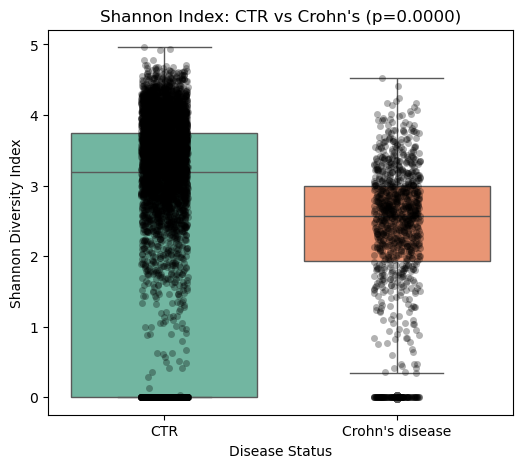

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.boxplot(data=final_combined_df, x='subject_disease_status', y='shannon_index', palette='Set2')
sns.stripplot(data=final_combined_df, x='subject_disease_status', y='shannon_index', color='black', alpha=0.3)

plt.title(f'Shannon Index: CTR vs Crohn\'s (p={shannon_p:.4f})')
plt.ylabel('Shannon Diversity Index')
plt.xlabel('Disease Status')
plt.show()

In [31]:
# Create a male-only subset of your final data
male_df = final_combined_df[final_combined_df['sex'].str.lower() == 'male'].copy()

print(f"Number of male samples: {len(male_df)}")

Number of male samples: 3403


In [32]:
from scipy.stats import entropy

# 1. Identify species columns
species_cols = [col for col in male_df.columns if col.startswith('s__')]

# 2. Calculate Shannon Index for males only
male_df['shannon_index'] = male_df[species_cols].apply(
    lambda row: entropy(row) if row.sum() > 0 else 0, axis=1
)

# 3. Compare groups within the male cohort
male_shannon_p = compare_groups(
    df=male_df, 
    group_col='subject_disease_status', 
    target_col='shannon_index', 
    group1='CTR', 
    group2="Crohn's disease", 
    subset_name="Male-Only Alpha Diversity"
)

--- Male-Only Alpha Diversity Comparison ---
CTR (n=2880) vs Crohn's disease (n=523)
P-value: 0.0000


In [33]:
# Filter out samples where sequencing may have failed (Shannon = 0)
male_df_clean = male_df[male_df['shannon_index'] > 0].copy()

# Run comparison on the cleaned male data
male_shannon_p = compare_groups(
    df=male_df_clean, 
    group_col='subject_disease_status', 
    target_col='shannon_index', 
    group1='CTR', 
    group2="Crohn's disease", 
    subset_name="Cleaned Male-Only Alpha Diversity"
)

--- Cleaned Male-Only Alpha Diversity Comparison ---
CTR (n=1884) vs Crohn's disease (n=466)
P-value: 0.0000


/tmp/ipykernel_8218/3676339126.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


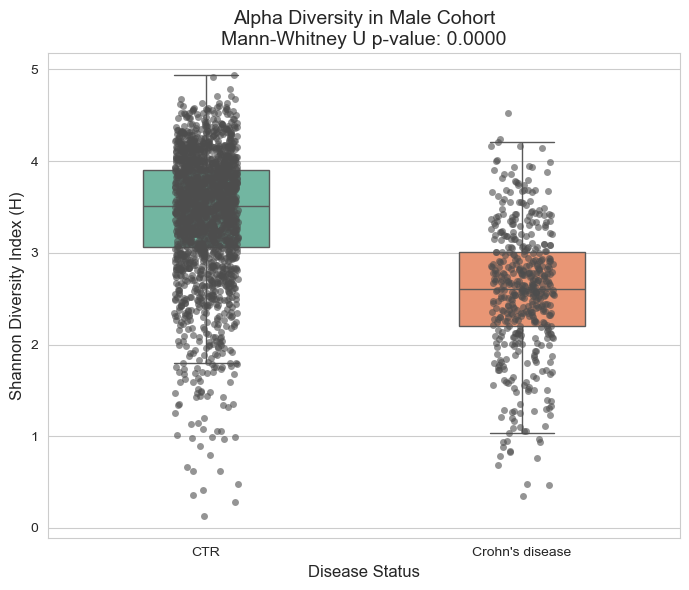

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import entropy, mannwhitneyu

# 1. Filter for Males and ensure valid data
male_df = final_combined_df[final_combined_df['sex'].str.lower() == 'male'].copy()

# 2. Calculate Shannon Index for species columns (starting with s__)
species_cols = [col for col in male_df.columns if col.startswith('s__')]
male_df['shannon_index'] = male_df[species_cols].apply(
    lambda row: entropy(row) if row.sum() > 0 else 0, axis=1
)

# 3. Clean: Remove samples where sequencing might have failed (Shannon = 0)
male_df_clean = male_df[male_df['shannon_index'] > 0].copy()

# 4. Perform Mann-Whitney U test for the plot title
g1 = male_df_clean[male_df_clean['subject_disease_status'] == 'CTR']['shannon_index']
g2 = male_df_clean[male_df_clean['subject_disease_status'] == "Crohn's disease"]['shannon_index']
stat, p_val = mannwhitneyu(g1, g2)

# 5. Create the Visualization
plt.figure(figsize=(7, 6))
sns.set_style("whitegrid")

# Create Boxplot
sns.boxplot(
    data=male_df_clean, 
    x='subject_disease_status', 
    y='shannon_index', 
    order=['CTR', "Crohn's disease"],
    palette={'CTR': '#66c2a5', "Crohn's disease": '#fc8d62'}, # Teal and Orange
    width=0.4,
    showfliers=False # Hide outliers to prevent double-plotting with stripplot
)

# Overlay individual data points (Stripplot)
sns.stripplot(
    data=male_df_clean, 
    x='subject_disease_status', 
    y='shannon_index', 
    order=['CTR', "Crohn's disease"],
    color='.3', 
    alpha=0.6, 
    jitter=True
)

# Add Labels and Statistical Significance
plt.title(f'Alpha Diversity in Male Cohort\nMann-Whitney U p-value: {p_val:.4f}', fontsize=14)
plt.ylabel('Shannon Diversity Index (H)', fontsize=12)
plt.xlabel('Disease Status', fontsize=12)

plt.tight_layout()
plt.savefig('male_shannon_comparison.png')
plt.show()